<a href="https://colab.research.google.com/github/elliottcoops/MNIST-Neural-Network/blob/main/Image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_digits
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [17]:
# Sigmoid and derivative of sigmoid functions
def sigmoid(z):
  return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
  return sigmoid(z) * (1 - sigmoid(z))

In [5]:
# Initialise random weights
# Each element in the matrix corrasponds to a neuron in layer: W_neuronFrom_neuronTo
def create_network(layers):
  x = []
  for i in range(1,len(layers)):
    x.append(np.random.randn(layers[i], layers[i-1]))
  return x

In [6]:
# Set up features and target
digits = load_digits()
X = digits.data
y = pd.get_dummies(digits.target).values

In [7]:
# Find max value and scale dataset
max_X = np.amax(X)
X /= max_X

In [8]:
# Split data in train, validation and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=42, shuffle=True)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42, shuffle=True)

X_train, X_test, X_val = X_train.T, X_test.T, X_val.T
y_train, y_test, y_val = y_train.T, y_test.T, y_val.T

In [20]:
learning_rate = 0.001
weights = create_network([64,16,32,16,10])
train_loss, val_loss = [], []
for epoch in range(10000):

  # Forward pass
  Z, A = [], []
  Z_val, A_val = [], []

  for i in range(len(weights)):
    Z.append((np.dot(weights[i], X_train)) if i == 0 else np.dot(weights[i], A[-1]))
    A.append(sigmoid(Z[-1]))

    Z_val.append((np.dot(weights[i], X_val)) if i == 0 else np.dot(weights[i], A_val[-1]))
    A_val.append(sigmoid(Z_val[-1]))

  # Append loss
  train_loss.append((np.sum((A[-1]-y_train)**2)) / (2 * len(y_train.T)))
  val_loss.append((np.sum((A_val[-1]-y_val)**2)) / (2 * len(y_val.T)))

  # Backward pass
  node_delta = []
  for i in range(len(weights)-1,-1,-1):
    node_delta.append((sigmoid_derivative(Z[-1]) * (A[-1] - y_train)) if i == len(weights) - 1 else (sigmoid_derivative(Z[i]) * np.dot(weights[i+1].T, node_delta[-1])))
    weight_delta = (np.dot(node_delta[-1], A[i-1].T)) if i != 0 else (np.dot(node_delta[-1], X_train.T))
    weights[i] -= learning_rate * (weight_delta)

KeyboardInterrupt: ignored

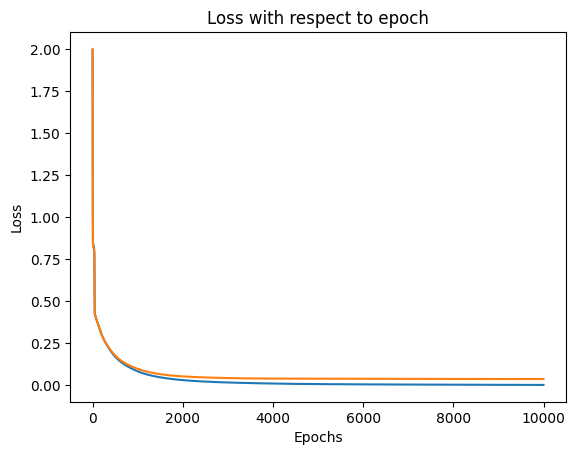

In [10]:
# Plot training and validation loss to check for overfitting
plt.plot(train_loss)
plt.plot(val_loss)
plt.title("Loss with respect to epoch")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [19]:
# Display final training loss
print(f"Final training loss: {train_loss[-1]}")

NameError: ignored

In [12]:
# Pass the training features through the network
for i in range(len(weights)):
  Z.append((np.dot(weights[i], X_test)) if i == 0 else np.dot(weights[i], A[-1]))
  A.append(sigmoid(Z[-1]))

In [13]:
# Plot a confusion matrix with the test values
y_pred = np.argmax(A[-1].T, axis=1)
y_actual = np.argmax(y_test.T, axis=1)
confusion_matrix(y_actual, y_pred)

array([[28,  0,  1,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 28,  0,  0,  0,  0,  0,  0,  1,  0],
       [ 0,  0, 29,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  1,  0, 32,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0, 30,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  1, 28,  0,  0,  0,  2],
       [ 1,  0,  0,  0,  0,  0, 26,  0,  0,  0],
       [ 0,  0,  0,  1,  0,  0,  0, 31,  0,  0],
       [ 0,  1,  0,  0,  0,  0,  0,  0, 29,  0],
       [ 0,  0,  1,  0,  1,  0,  0,  0,  0, 28]])

<ipython-input-14-92dcd3392ba4>:6: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax = plt.subplot(rows, cols, i+1)


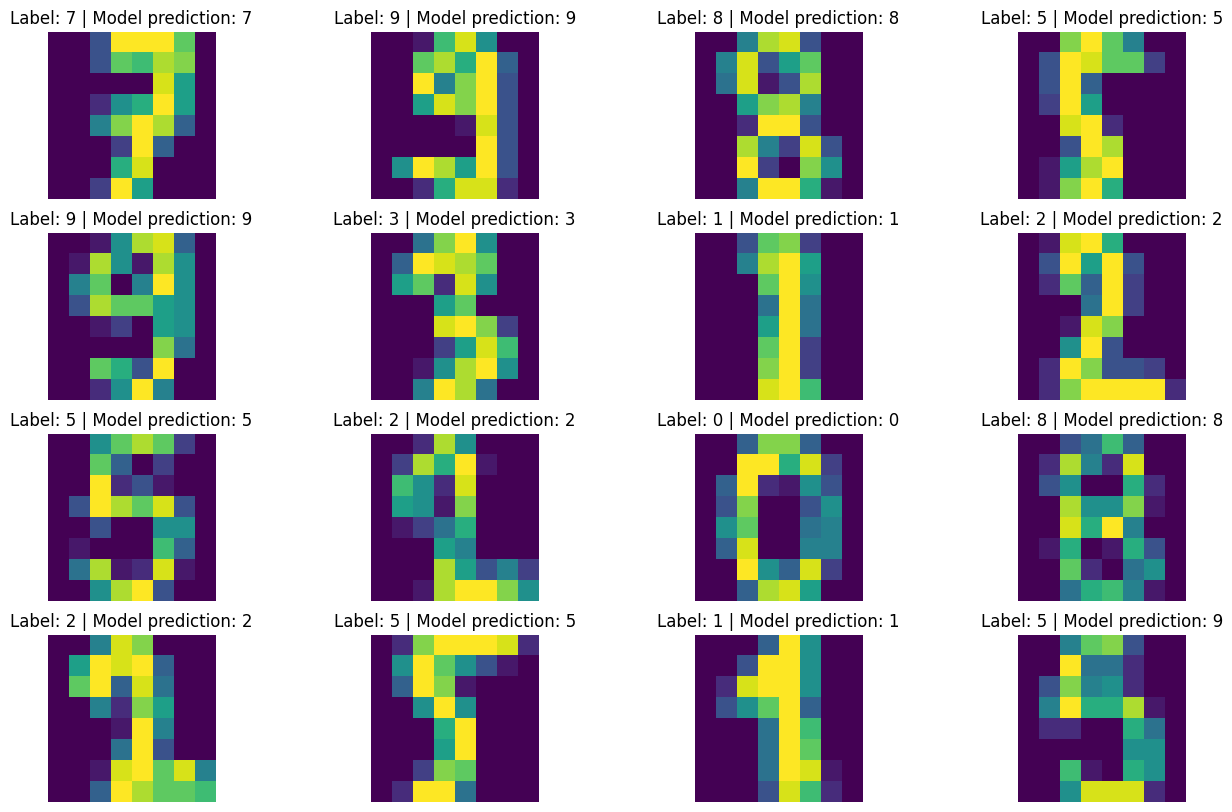

In [14]:
# Display labels and predictions
ims = X_test.T

rows, cols = 4, 4
plt.subplots(figsize=(16,10))
for i in range(rows*cols):
  ax = plt.subplot(rows, cols, i+1)
  ax.set_axis_off()
  ax.imshow(ims[i].reshape(8,8))
  ax.set_title(f"Label: {y_actual[i]} | Model prediction: {y_pred[i]}")

plt.show()

In [15]:
# Calculate accuracy
number_of_samples = len(y_test.T)
accuracy = [1 if y_pred[i] == y_actual[i] else 0 for i in range(number_of_samples)]
accuracy = round(sum(accuracy) / number_of_samples, 2) * 100
print(f"Final accuracy of model: {accuracy}% (2dp)")

Final accuracy of model: 96.0% (2dp)
